### Setup

In [14]:
!./venv/bin/pip install kaggle scikit-learn numpy matplotlib seaborn crucio tqdm


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
!kaggle datasets download --unzip -d abcsds/pokemon

Dataset URL: https://www.kaggle.com/datasets/abcsds/pokemon
License(s): CC0-1.0
100%|██████████████████████████████████████| 14.9k/14.9k [00:00<00:00, 19.8MB/s]



### Imports

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.covariance import EllipticEnvelope
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, ConfusionMatrixDisplay, classification_report, roc_curve, roc_auc_score
from crucio import SMOTE, SMOTEENN, ICOTE, TKRKNN, ADASYN, SMOTENC, SCUT, MWMOTE, SLS, SMOTETOMEK
from collections import Counter
from tqdm import tqdm

### Load Dataset

In [6]:
df = pd.read_csv("Pokemon.csv")

In [ ]:
df.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


In [ ]:
df.describe()

,#,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation
count,800.000000,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.00000
mean,362.813750,435.10250,69.258750,79.001250,73.842500,72.820000,71.902500,68.277500,3.32375
std,208.343798,119.96304,25.534669,32.457366,31.183501,32.722294,27.828916,29.060474,1.66129
min,1.000000,180.00000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,1.00000
25%,184.750000,330.00000,50.000000,55.000000,50.000000,49.750000,50.000000,45.000000,2.00000
50%,364.500000,450.00000,65.000000,75.000000,70.000000,65.000000,70.000000,65.000000,3.00000
75%,539.250000,515.00000,80.000000,100.000000,90.000000,95.000000,90.000000,90.000000,5.00000
max,721.000000,780.00000,255.000000,190.000000,230.000000,194.000000,230.000000,180.000000,6.00000


In [ ]:
df.duplicated().sum()

np.int64(0)

### Choosing Two Columns

First, I want to know the value counts for columns of type string.

We can see that name is a unique value, even though the name can be composite (e.g. Venusaur and VenusaurMega Venusaur), I doubt it is worth trying to encode it. Type 1 and Type 2 columns also have a high diversity in values, so they are also candidates to be dropped.

In [ ]:
str_cols = ['Name', 'Type 1', 'Type 2']
for col in str_cols:
    print(df[col].value_counts())

Name
Bulbasaur                1
Ivysaur                  1
Venusaur                 1
VenusaurMega Venusaur    1
Charmander               1
                        ..
Diancie                  1
DiancieMega Diancie      1
HoopaHoopa Confined      1
HoopaHoopa Unbound       1
Volcanion                1
Name: count, Length: 800, dtype: int64
Type 1
Water       112
Normal       98
Grass        70
Bug          69
Psychic      57
Fire         52
Electric     44
Rock         44
Ground       32
Ghost        32
Dragon       32
Dark         31
Poison       28
Fighting     27
Steel        27
Ice          24
Fairy        17
Flying        4
Name: count, dtype: int64
Type 2
Flying      97
Ground      35
Poison      34
Psychic     33
Fighting    26
Grass       25
Fairy       23
Steel       22
Dark        20
Dragon      18
Ice         14
Rock        14
Water       14
Ghost       14
Fire        12
Electric     6
Normal       4
Bug          3
Name: count, dtype: int64


Type 2 also has many missing values

In [ ]:
df.isna().sum()

#               0
Name            0
Type 1          0
Type 2        386
Total           0
HP              0
Attack          0
Defense         0
Sp. Atk         0
Sp. Def         0
Speed           0
Generation      0
Legendary       0
dtype: int64

In [ ]:
df.groupby("Legendary")["Type 1"].value_counts()

Legendary  Type 1  
False      Water       108
           Normal       96
           Bug          69
           Grass        67
           Fire         47
           Psychic      43
           Rock         40
           Electric     40
           Ghost        30
           Dark         29
           Ground       28
           Poison       28
           Fighting     27
           Steel        23
           Ice          22
           Dragon       20
           Fairy        16
           Flying        2
True       Psychic      14
           Dragon       12
           Fire          5
           Ground        4
           Steel         4
           Rock          4
           Water         4
           Electric      4
           Grass         3
           Normal        2
           Flying        2
           Dark          2
           Ghost         2
           Ice           2
           Fairy         1
Name: count, dtype: int64

In [7]:
clean_df = df.copy()#.drop(columns=['Type 1', 'Type 2'])

In [8]:
clean_df

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,719,Diancie,Rock,Fairy,600,50,100,150,100,150,50,6,True
796,719,DiancieMega Diancie,Rock,Fairy,700,50,160,110,160,110,110,6,True
797,720,HoopaHoopa Confined,Psychic,Ghost,600,80,110,60,150,130,70,6,True
798,720,HoopaHoopa Unbound,Psychic,Dark,680,80,160,60,170,130,80,6,True


Drop index column

In [8]:
clean_df.drop(clean_df.columns[0], axis=1, inplace=True)

Let's convert Legendary to 0/1 values to create a correlation heatmap

In [9]:
clean_df['Legendary'] = clean_df['Legendary'].replace({True: 1, False: 0})

In [ ]:
clean_df["Type 2 Missing"] = clean_df["Type 2"].isna().astype(int)

In [10]:
clean_df.drop(columns=['Name', 'Type 1', 'Type 2'], inplace=True, errors="ignore")

In [11]:
clean_df.head()

,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,318,45,49,49,65,65,45,1,0
1,405,60,62,63,80,80,60,1,0
2,525,80,82,83,100,100,80,1,0
3,625,80,100,123,122,120,80,1,0
4,309,39,52,43,60,50,65,1,0


In [ ]:
clean_df["Type 2 Missing"].value_counts()

Type 2 Missing
0    414
1    386
Name: count, dtype: int64

<Axes: >

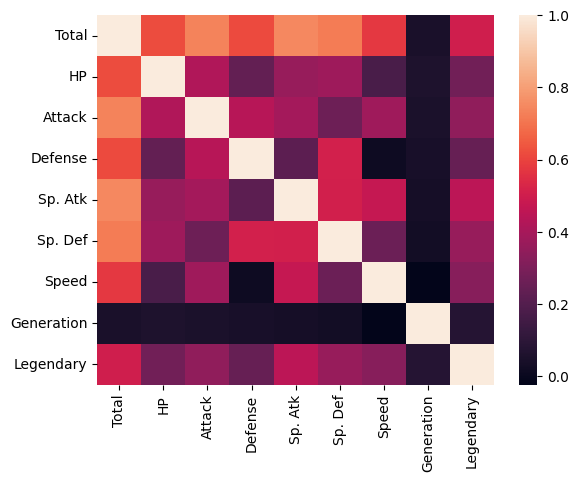

In [ ]:
corr = clean_df.corr()
sns.heatmap(corr)

`Total` and `Sp. Atk` seem to have the most correlation to `Legendary` (target column), so we are going to use them for outlier detection.

In [ ]:
corr['Legendary'].sort_values(ascending=False)

Legendary     1.000000
Total         0.501758
Sp. Atk       0.448907
Sp. Def       0.363937
Attack        0.345408
Speed         0.326715
HP            0.273620
Defense       0.246377
Generation    0.079794
Name: Legendary, dtype: float64

In [ ]:
outlier_df = clean_df[['Total', 'Sp. Atk']]
outlier_df.head()

,Total,Sp. Atk
0,318,65
1,405,80
2,525,100
3,625,122
4,309,60


### Visualization

#### Plot Legendary Entries

Our goal is to predict whether or not a pokemon is legendary. However, a pokemon being legendary is a rare sight, and it is more likely that a legendary pokemon is an outlier.

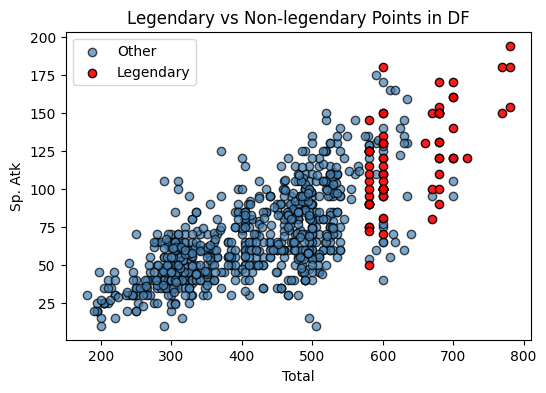

In [ ]:
legendary_mask = clean_df["Legendary"] == True

plt.figure(figsize=(6, 4))
plt.scatter(
    clean_df.loc[~legendary_mask, "Total"],
    clean_df.loc[~legendary_mask, "Sp. Atk"],
    c="steelblue", label="Other", alpha=0.7, edgecolors="k"
)
plt.scatter(
    clean_df.loc[legendary_mask, "Total"],
    clean_df.loc[legendary_mask, "Sp. Atk"],
    c="red", label="Legendary", alpha=0.9, edgecolors="k"
)
plt.xlabel("Total")
plt.ylabel("Sp. Atk")
plt.title("Legendary vs Non-legendary Points in DF")
plt.legend()

#### Normalization

Before proceeding with outlier detection, let's normalize the columns. To do that, plot the columns to see which scalind method applies the best

<Axes: ylabel='Density'>

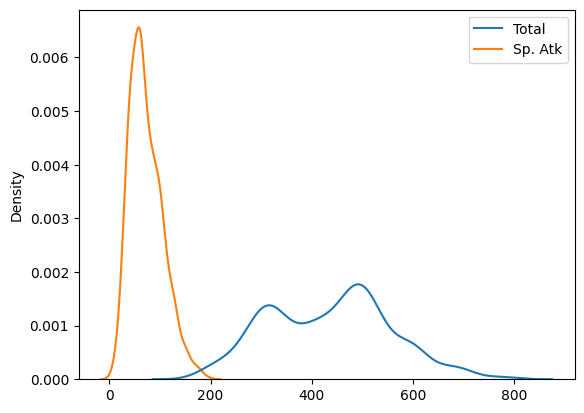

In [ ]:
sns.kdeplot(data=outlier_df)

The plots look like a normal distribution, so we can applying `StandardScaler` would be a good choice

#### Box Plot

According to box plot, `Total` column has no outliers, while `Sp. Atk` column has some outliers outside the maximum range of values.

<Axes: >

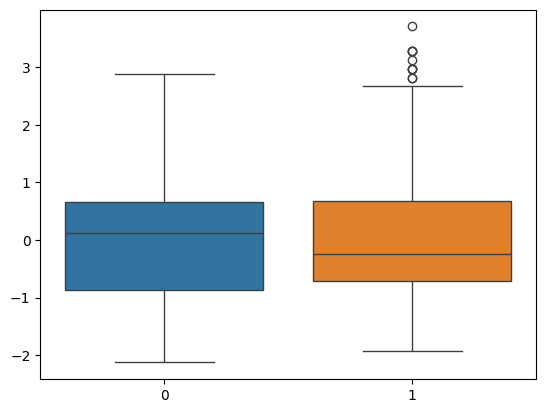

In [ ]:
sns.boxplot(data=outlier_df)

### Training the Models

#### Train/test split

In [12]:
X = clean_df.drop(columns=['Legendary', 'Generation'])
y = clean_df['Legendary'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#### Defining Prediction Pipeline

In [30]:
def get_predictor_pipeline(predictor_class, balancing_model_class):
    outlier_pipeline = make_pipeline(StandardScaler(), LocalOutlierFactor())
    labels = outlier_pipeline.fit_predict(X_train)
    keep_rows = (labels == 1)

    X_train_proc = X_train.copy()#.loc[keep_rows]
    y_train_proc = y_train.copy()#.loc[keep_rows]

    # Crucio balancers can drop rows by positional integer index; use a clean RangeIndex.
    proc_df = X_train_proc.copy().reset_index(drop=True)
    proc_df.columns = X_train.columns
    proc_df["Legendary"] = y_train_proc.reset_index(drop=True).astype(int)

    balanced_df = balancing_model_class().balance(proc_df, 'Legendary')

    X_train_balanced = balanced_df.drop(columns=['Legendary'])
    y_train_balanced = balanced_df["Legendary"]

    predictor_pipeline = make_pipeline(StandardScaler(), predictor_class())
    predictor_pipeline.fit(X_train_balanced, y_train_balanced)

    return predictor_pipeline, X_train_balanced, y_train_balanced

#### Balancing Models

SMOTE - identifies minority class sample, finds its k neighbours, and generates a synthetic sample on the line between the given sample and its neighbor (might be noisy if the neighbours are not so near)

SMOTEENN - improvement over SMOTE, as it uses ENN (edited nearest neighbours) that identifies local "outliers" for the given class and prevents SMOTE from using them

ICOTE - generates clones of a minority class that is among a majority class to balance out their number

ADASYN - finds k nearest neighbours of "hard-to-learn" examples and generates synthetic points in its vicinity to improve the decision boundary between the classes

SMOTENC - same principle as SMOTE, but it encodes categorical columns into continuous numbers in a useful manner

SCUT - oversamples the minority class by taking into account the within-class and between-class imbalance 

MWMOTE - measures the euclidean distance between clusters of minority classes and populates them proportionally to that distance

SMOTETOMEK - improvement over SMOTE, uses Tomek links to remove the majority class points that are the closest to synthetically generated minority class samples

SLS - improvement over SMOTE, classifies points into safe levels and generates synthetic rows closer to the safe zone


#### Choosing Best Model/SMOTE combo

As classifier models, I chose three different approaches: linear (LogisticRegression), nearest neighbors (KNeighborsClassifier), and ensemble / random forest (RandomForestClassifier)

I chose a subset of balancing models from crucio library to see which one performs the best

Main evaluation metric will be f1-score to ensure that the model performs well on both classes.

In [31]:
predictors = [LogisticRegression, KNeighborsClassifier, RandomForestClassifier]
balancing_models = [SMOTE, SMOTEENN, ICOTE, ADASYN, SMOTENC, MWMOTE, SLS, SMOTETOMEK]

results = {
    "train": {},
    "test": {}
}

for predictor_class in tqdm(predictors, desc="Predictors"):
    predictor_name = predictor_class.__name__
    results["train"][predictor_name] = {}
    results["test"][predictor_name] = {}

    for balancing_model_class in balancing_models:
        outlier_name = balancing_model_class().__class__.__name__
        predictor_pipeline, X_train_balanced, y_train_balanced = get_predictor_pipeline(predictor_class, balancing_model_class)

        y_train_pred = predictor_pipeline.predict(X_train_balanced)
        y_test_pred = predictor_pipeline.predict(X_test)

        results["train"][predictor_name][outlier_name] = {
            "f1": f1_score(y_train_balanced, y_train_pred, zero_division=0),
            "acc": accuracy_score(y_train_balanced, y_train_pred)
        }
        results["test"][predictor_name][outlier_name] = {
            "f1": f1_score(y_test, y_test_pred, zero_division=0),
            "acc": accuracy_score(y_test, y_test_pred)
        }

Predictors: 100%|██████████| 3/3 [00:07<00:00,  2.55s/it]


In [18]:
def heatmap_for(dict_key, metric, ax):

    metric_data = {
        predictor_name: {
            outlier_name: scores[metric]
            for outlier_name, scores in outlier_scores.items()
        }
        for predictor_name, outlier_scores in results[dict_key].items()
    }

    df = pd.DataFrame.from_dict(metric_data, orient="index")

    sns.heatmap(df, annot=True, fmt=".3f", vmin=0, vmax=1, ax=ax)
    ax.set_title(f"{dict_key} {metric.upper()}")
    ax.set_xlabel("Balancing method")
    ax.tick_params(axis="x", labelrotation=45)
    ax.tick_params(axis="y", labelrotation=45)

##### Without Outlier detection

Primary focus should be on the test F1 heatmap. 

When looking at the models, across almost all balancing method RandomForestClassifier performed the best.

When it comes to the balancing models, the highest F1 score on the test dataset was achieved using SMOTE, SMOTENC, and SMOTETOMEK.

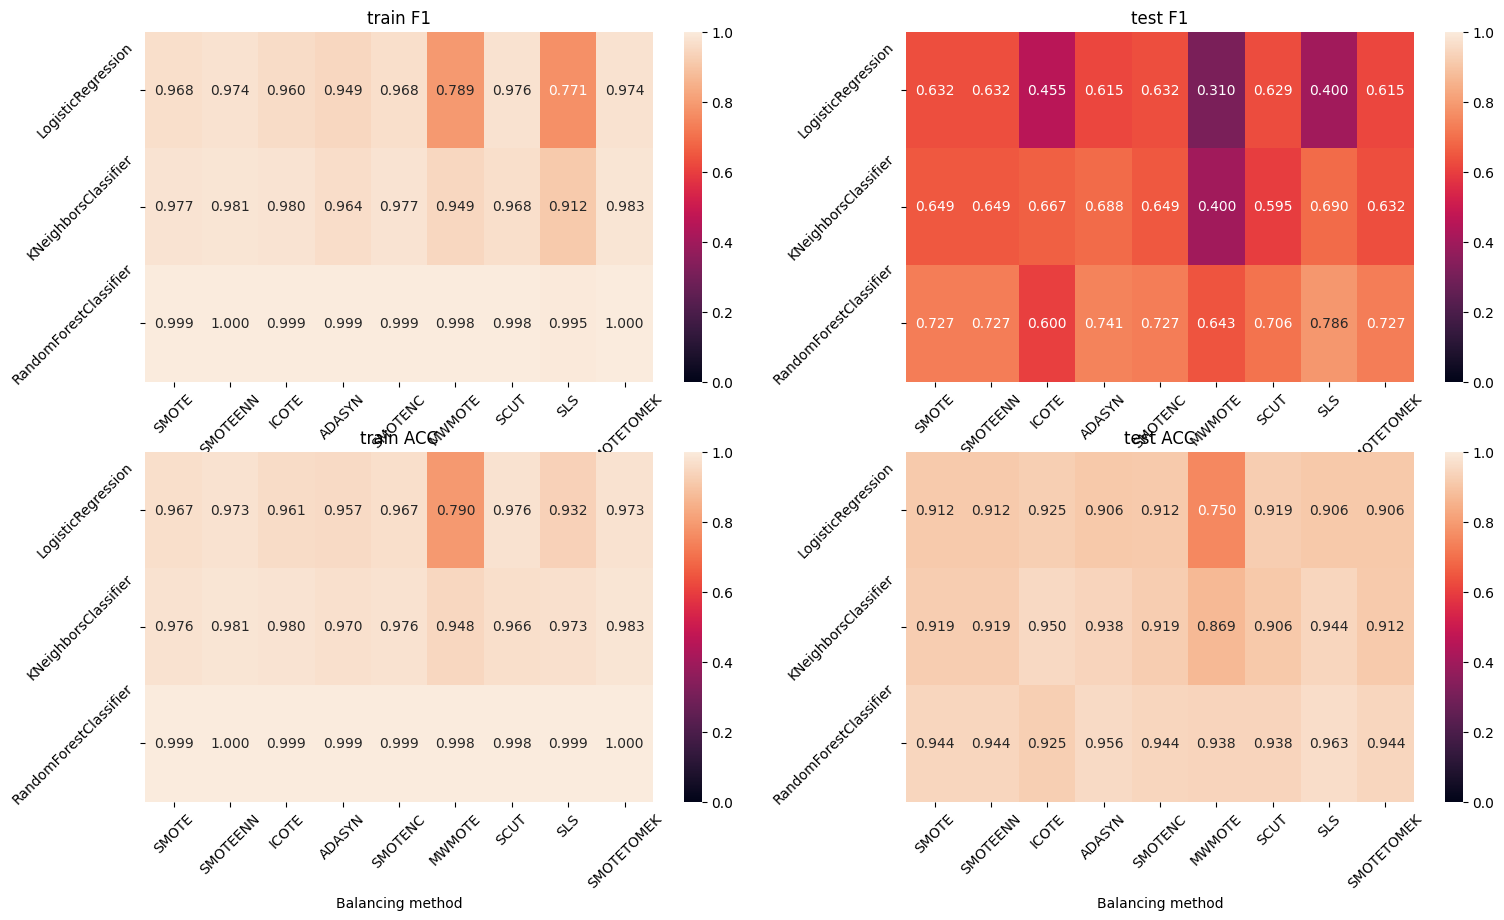

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

heatmap_for("train", "f1", axes[0, 0])
heatmap_for("test", "f1", axes[0, 1])
heatmap_for("train", "acc", axes[1, 0])
heatmap_for("test", "acc", axes[1, 1])

##### Best Model w/o Outlier Removal

Let's see some performance insights for the best model/balancing method combo. For the balancing method, let's choose SMOTE.

###### Confusion Matrix

Only one pokemon was mislabeled as being legendary, even though it was a regular one. This model tends to classify legendary pokemon as regular ones. That is because some legendary pokemons are very close in terms of statistics to regular ones, and that is genuinely hard to predict, even for a human being.

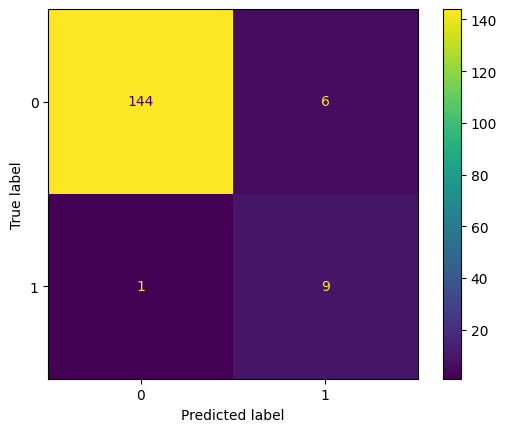

In [ ]:
predictor_pipeline, X_train_proc, y_train_proc = get_predictor_pipeline(RandomForestClassifier, SMOTE)
y_train_pred = predictor_pipeline.predict(X_train_proc)
y_test_pred = predictor_pipeline.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred)

###### Classification Report

Final F1 score for RandomForestClassifier in combination with SMOTE is 0.96. Most importantly, precision and recall are 0.60 or higher, which is quite good for this dataset.

In [ ]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.99      0.96      0.98       150
           1       0.60      0.90      0.72        10

    accuracy                           0.96       160
   macro avg       0.80      0.93      0.85       160
weighted avg       0.97      0.96      0.96       160



###### ROC-AUC score

We can achieve a perfect True positive rate with a False Positive rate of just ~0.07. AUC Score of 0.982 indicates a very high accuracy.

In [ ]:
def plot_roc_curve(y_true, y_proba):
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    plt.plot(fpr, tpr)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')

AUC Score: 0.982


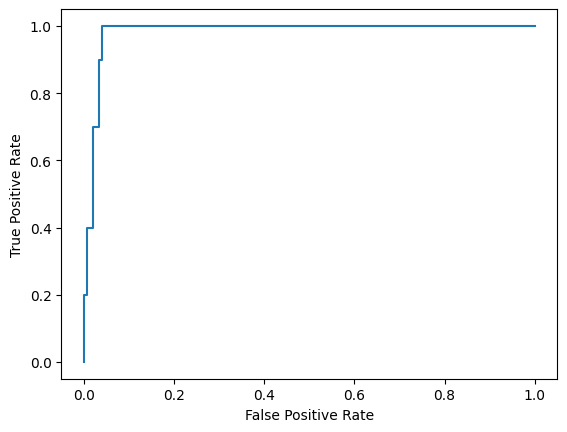

In [ ]:
y_proba = predictor_pipeline.predict_proba(X_test)
y_proba_pos = y_proba[:, 1]
plot_roc_curve(y_test, y_proba_pos)
print(f"AUC Score: {roc_auc_score(y_test, y_proba_pos)}")

##### With LocalOutlierFactor

To my surprise, applying LocalOutlierFactor on the dataset degraded the class balancing and led to a worse performance of the models. Generating more data points with outliers present in the dataset creates a more balanced dataset, even though for me it seems counter-intuitive.

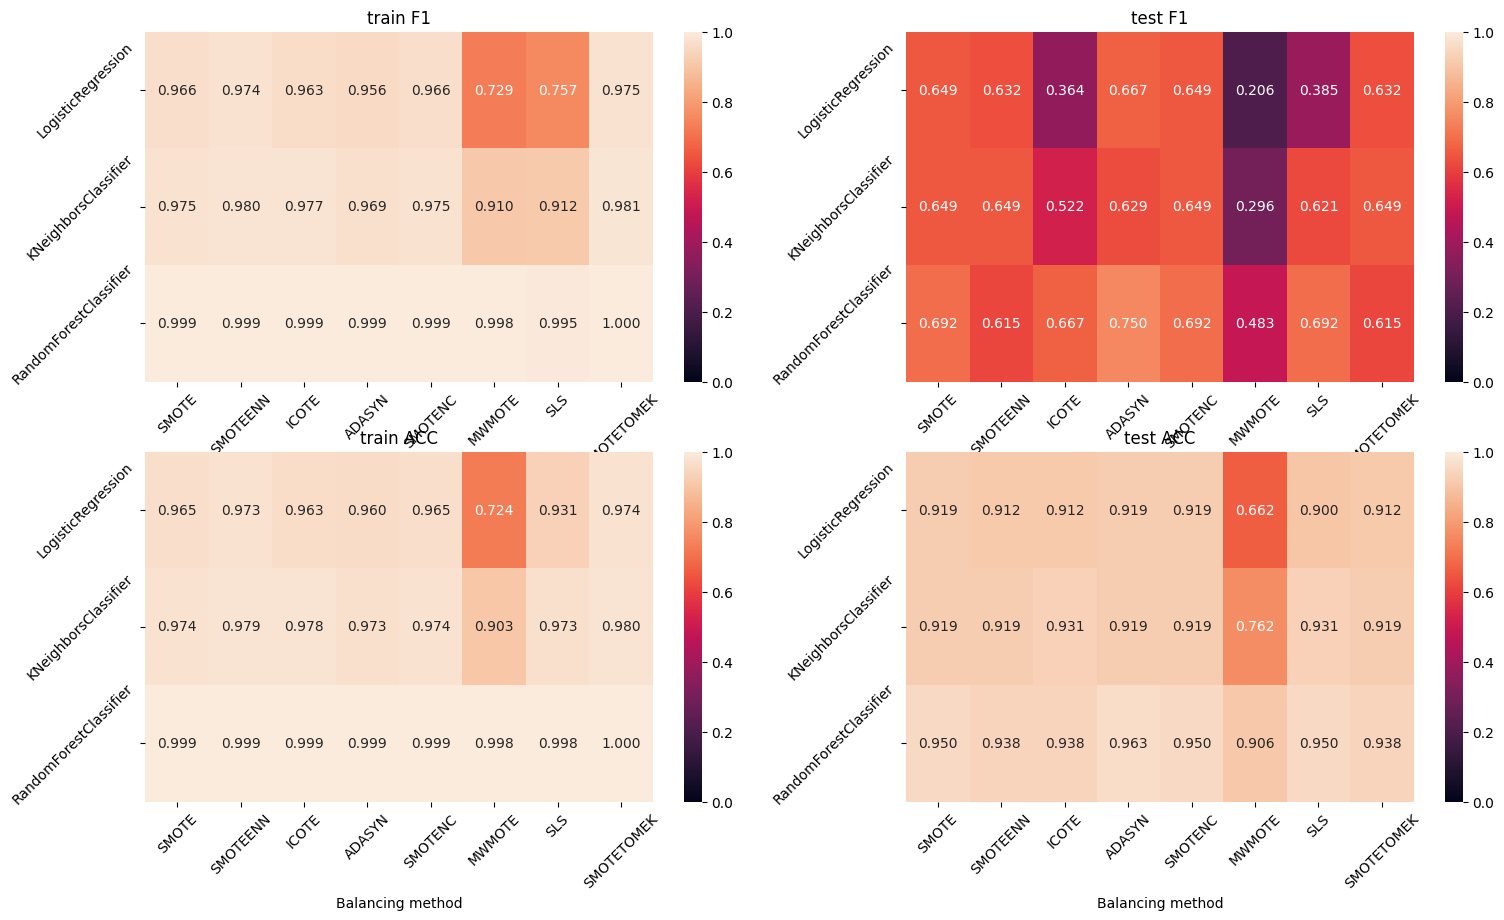

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

heatmap_for("train", "f1", axes[0, 0])
heatmap_for("test", "f1", axes[0, 1])
heatmap_for("train", "acc", axes[1, 0])
heatmap_for("test", "acc", axes[1, 1])

##### Original vs Synthetic Dataset Plot

In [ ]:
def plot_balanced_df(df):
    plot_cols = ["Total", "Sp. Atk", "Legendary"]

    clean_points = clean_df[plot_cols].copy()
    clean_points["Legendary"] = clean_points["Legendary"].astype(int)
    balanced_points = df[plot_cols].copy()
    balanced_points["Legendary"] = balanced_points["Legendary"].round().astype(int)

    available = Counter(map(tuple, clean_points.to_numpy()))
    exists_in_clean = []
    for row in map(tuple, balanced_points.to_numpy()):
        if available[row] > 0:
            exists_in_clean.append(True)
            available[row] -= 1
        else:
            exists_in_clean.append(False)

    balanced_points["exists_in_clean"] = exists_in_clean

    existing_points = balanced_points[balanced_points["exists_in_clean"]]
    added_points = balanced_points[~balanced_points["exists_in_clean"]]

    # Same scale on both subplots for visual comparability.
    x_min = balanced_points["Total"].min()
    x_max = balanced_points["Total"].max()
    y_min = balanced_points["Sp. Atk"].min()
    y_max = balanced_points["Sp. Atk"].max()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

    for ax, data, title in [
        (axes[0], existing_points, "Points that already exist in clean_df"),
        (axes[1], added_points, "Points added by balancing")
    ]:
        non_leg = data[data["Legendary"] == 0]
        leg = data[data["Legendary"] == 1]

        ax.scatter(
            non_leg["Total"], non_leg["Sp. Atk"],
            c="steelblue", marker="o", alpha=0.75, edgecolors="k",
            label="Non-legendary"
        )
        ax.scatter(
            leg["Total"], leg["Sp. Atk"],
            c="crimson", alpha=0.9, edgecolors="k",
            label="Legendary"
        )

        ax.set_title(title)
        ax.set_xlabel("Total")
        ax.set_ylabel("Sp. Atk")
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.legend()

    plt.suptitle("Original vs Synthetic Points by Class", y=1.02)
    plt.tight_layout()

##### Best SMOTE

I wanted to inspect how ICOTE generated the points to see how it lead to the best performance, considering the usage of LocalOutlierFactor. It has created more points for much larger values of the features, which makes sense in case of legendary pokemons, as they tend to have larger stats. We can also see how the newly created points tend to follow the same spread and elliptic pattern as the original dataset.

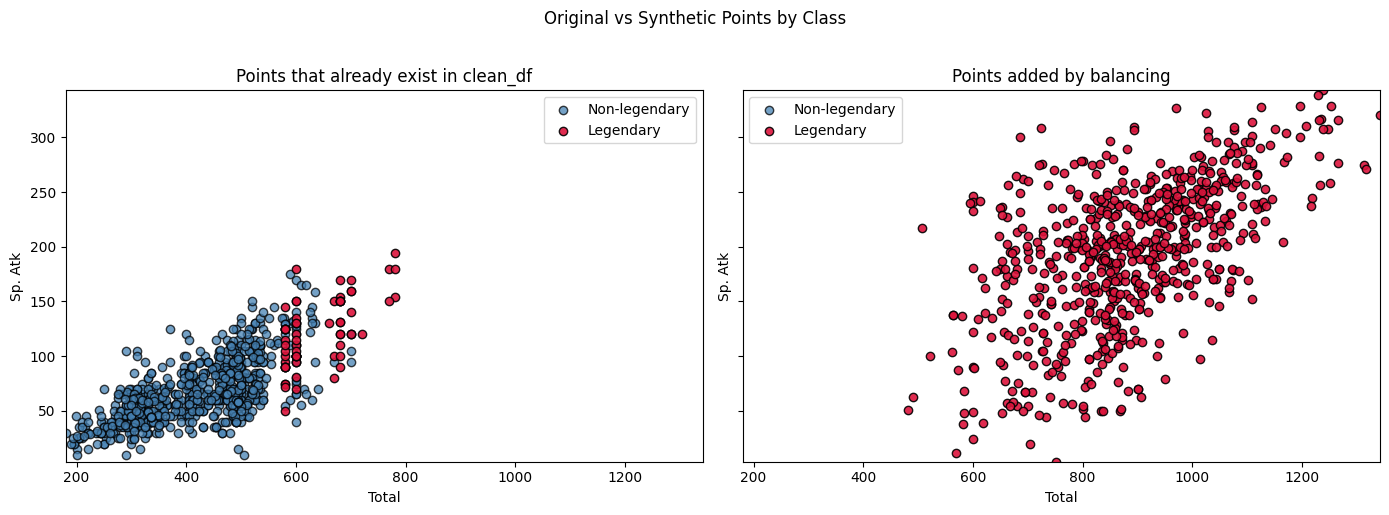

In [ ]:
icote_df = ICOTE().balance(clean_df, "Legendary").copy()
plot_balanced_df(icote_df)

###### Visualizing Erroneous Predictions

For this plot, we plot the original dataframe and the points that were mislabeled by the RandomForestClassifier model. It can be seen that the mislabeled ones are not evident legendary pokemons and are close to other regular ones. We can say that those errors are specific to the data provided.

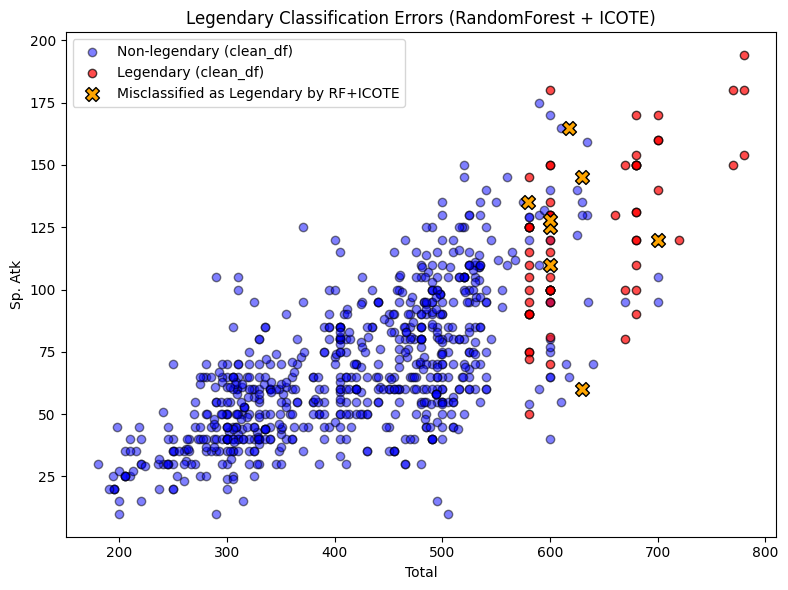

In [ ]:
predictor_pipeline_icote, _, _ = get_predictor_pipeline(RandomForestClassifier, ICOTE)
y_test_pred_icote = predictor_pipeline_icote.predict(X_test)

non_legendary_mask = clean_df["Legendary"].astype(int) == 0
legendary_mask = clean_df["Legendary"].astype(int) == 1

misclassified_legendary_mask = ((y_test == 0) & (y_test_pred_icote == 1))
misclassified_legendary_points = X_test.loc[misclassified_legendary_mask, ["Total", "Sp. Atk"]]

plt.figure(figsize=(8, 6))

# clean_df points
plt.scatter(
    clean_df.loc[non_legendary_mask, "Total"],
    clean_df.loc[non_legendary_mask, "Sp. Atk"],
    c="blue", alpha=0.5, edgecolors="k", label="Non-legendary (clean_df)"
)
plt.scatter(
    clean_df.loc[legendary_mask, "Total"],
    clean_df.loc[legendary_mask, "Sp. Atk"],
    c="red", alpha=0.7, edgecolors="k", label="Legendary (clean_df)"
)

# Misclassified test points
plt.scatter(
    misclassified_legendary_points["Total"],
    misclassified_legendary_points["Sp. Atk"],
    c="orange", s=100, marker="X", edgecolors="k",
    label="Misclassified as Legendary by RF+ICOTE"
)

plt.xlabel("Total")
plt.ylabel("Sp. Atk")
plt.title("Legendary Classification Errors (RandomForest + ICOTE)")
plt.legend()
plt.tight_layout()
plt.show()

###### Confusion Matrix

This model has not mislabeled any data points as non-legendary. All the error comes from marking regular pokemons as legendary. However, as we have seen from the previous plot, those points are not evident at all.

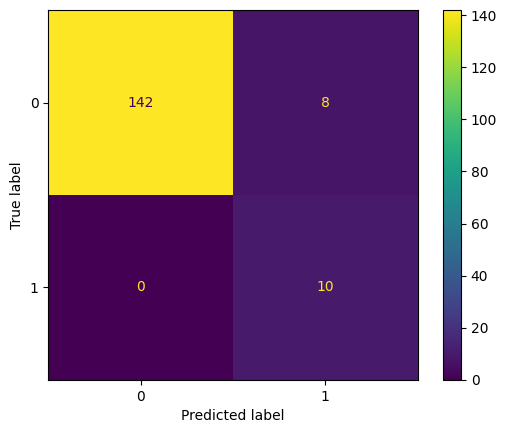

In [ ]:
predictor_pipeline, X_train_proc, y_train_proc = get_predictor_pipeline(RandomForestClassifier, ICOTE)
y_train_pred = predictor_pipeline.predict(X_train_proc)
y_test_pred = predictor_pipeline.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred)

###### Classification Report

Precision for legendary pokemons is a bit lower than for the pipeline without outlier detection. The result F1-score is almost equivalent.

In [ ]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97       150
           1       0.56      1.00      0.71        10

    accuracy                           0.95       160
   macro avg       0.78      0.97      0.84       160
weighted avg       0.97      0.95      0.96       160



###### ROC-AUC score

Here, we achieve a better AUC score due to the fact that our model has False Negative rate of zero and a higher True Positive accuracy.

AUC Score: 0.9843333333333333


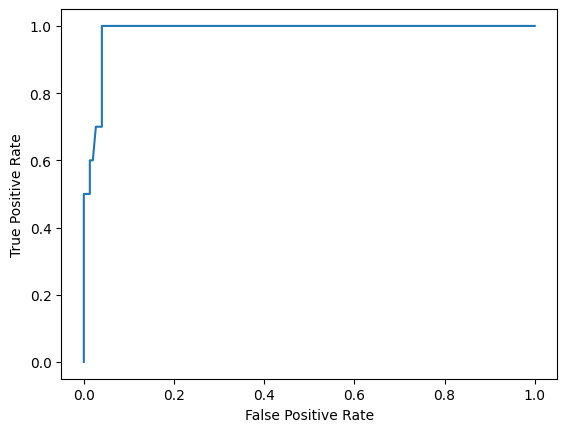

In [ ]:
y_proba = predictor_pipeline.predict_proba(X_test)
y_proba_pos = y_proba[:, 1]
plot_roc_curve(y_test, y_proba_pos)
print(f"AUC Score: {roc_auc_score(y_test, y_proba_pos)}")

##### Worst SMOTE

MWMOTE created legendary pokemons in the middle of the non-legendary pokemon clusterm which does not make sense in the context of the given dataset, hence the accuracy using this class balancing method is very low.

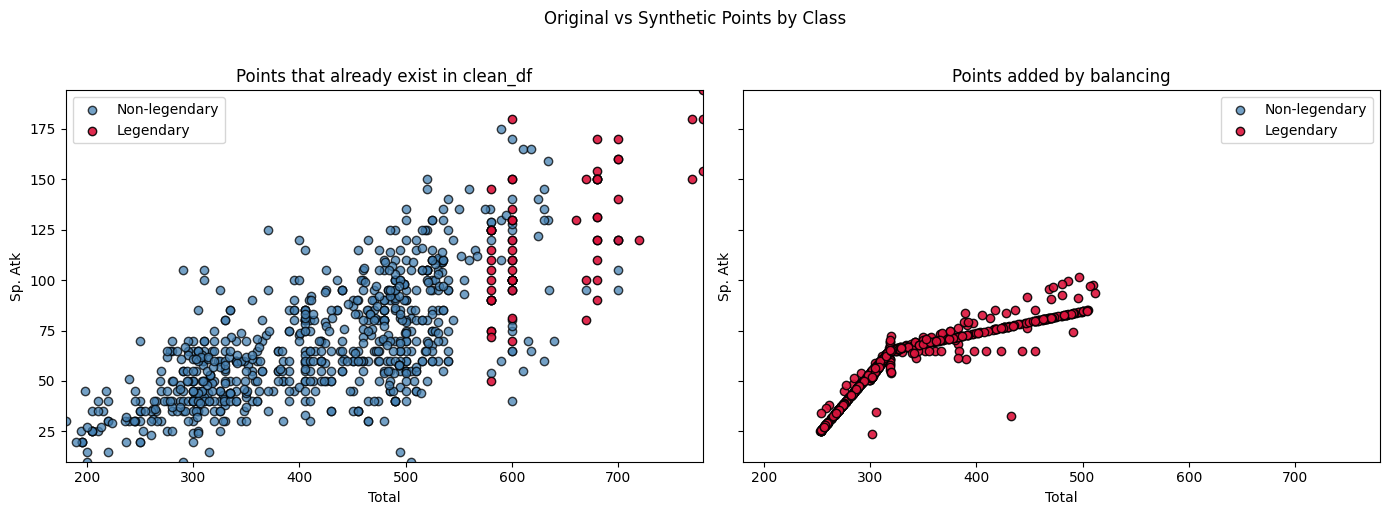

In [ ]:
mwmote_df = MWMOTE().balance(clean_df, "Legendary").copy()
plot_balanced_df(mwmote_df)

# Balancing Models ranked by test F1 score

In [32]:
metric_data = {
    predictor_name: {
        outlier_name: scores["f1"]
        for outlier_name, scores in outlier_scores.items()
    }
    for predictor_name, outlier_scores in reversed(results["test"].items())
}

pd.DataFrame.from_dict(metric_data, orient="index").T.sort_values(by="RandomForestClassifier", ascending=False)

,RandomForestClassifier,KNeighborsClassifier,LogisticRegression
SLS,0.785714,0.689655,0.400000
ADASYN,0.740741,0.687500,0.615385
SMOTE,0.727273,0.648649,0.631579
SMOTEENN,0.727273,0.648649,0.631579
SMOTENC,0.727273,0.648649,0.631579
SMOTETOMEK,0.727273,0.631579,0.615385
MWMOTE,0.642857,0.400000,0.310345
ICOTE,0.600000,0.666667,0.454545


# Conclusion

SMOTE is a powerful class balancing tool that helps creating synthetic samples for undersampled classes. However, there are many modifications that can be useful for different scenarios. SMOTENC can be used with categorical columns, SLS creates "safe" points that will minimially change the decision boundary, ICOTE focuses on local minority clusters etc. Each class balancer has its applications, situations where they will yield a good performance or, inversely, a bad one. Choosing the best class balancer may be done analytically, but can also be done by testing each class balancer on a given dataset.